In [1]:
import os
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import timm

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
)

sns.set(style="whitegrid")

In [2]:
BASE_PATH = Path(r"E:\Thesis")

PAD_PATH = BASE_PATH / "PAD-UFES-20"
PAD_IMAGE_DIR = PAD_PATH / "images"
PAD_META = PAD_PATH / "metadata.csv"

MODEL_PATH = BASE_PATH / "outputs" / "swin_tiny_baseline" / "best_swin_tiny.pth"

OUT_DIR = BASE_PATH / "outputs" / "swin_crossdomain_experiments"
OUT_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE = (224, 224)
BATCH_SIZE = 4
CLASS_NAMES = ["ACK", "BCC", "MEL", "NEV"]
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASS_NAMES)}

# Swin-T pretrained style normalization
MEAN = (0.485, 0.456, 0.406)
STD = (0.229, 0.224, 0.225)

print("PAD meta exists:", PAD_META.exists())
print("Model exists:", MODEL_PATH.exists())
print("Output dir:", OUT_DIR)

PAD meta exists: True
Model exists: True
Output dir: E:\Thesis\outputs\swin_crossdomain_experiments


In [3]:
pad = pd.read_csv(PAD_META)

pad_4 = pad[pad["diagnostic"].isin(CLASS_NAMES)].copy()
pad_4["label"] = pad_4["diagnostic"]
pad_4["image_path"] = pad_4["img_id"].apply(lambda x: str(PAD_IMAGE_DIR / x))
pad_4 = pad_4[pad_4["image_path"].apply(os.path.exists)].copy()

print("PAD samples:", len(pad_4))
print(pad_4["label"].value_counts())

PAD samples: 1871
label
BCC    845
ACK    730
NEV    244
MEL     52
Name: count, dtype: int64


In [4]:
def resolve_image_dir(folder: Path) -> Path:
    if (folder / "images").exists():
        return folder / "images"
    return folder

In [5]:
def build_df_from_folder(base_df: pd.DataFrame, folder: Path) -> pd.DataFrame:
    df = base_df.copy()
    df["image_path"] = df["img_id"].apply(lambda x: str(folder / x))
    df["exists"] = df["image_path"].apply(os.path.exists)
    df = df[df["exists"]].copy()
    return df

In [6]:
class PADDataset(Dataset):
    def __init__(self, dataframe: pd.DataFrame, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
        self.label_to_idx = CLASS_TO_IDX

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row["image_path"]
        label = row["label"]

        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)

        y = self.label_to_idx[label]
        return image, torch.tensor(y, dtype=torch.long)

In [7]:
def make_loader(df: pd.DataFrame, shuffle: bool = False):
    transform = transforms.Compose([
        transforms.Resize(IMG_SIZE),
        transforms.ToTensor(),
        transforms.Normalize(mean=MEAN, std=STD),
    ])

    dataset = PADDataset(df, transform=transform)
    loader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=0,
        pin_memory=torch.cuda.is_available()
    )
    return loader

In [8]:
def compute_metrics(true_classes, pred_classes, pred_probs, class_names):
    acc = accuracy_score(true_classes, pred_classes)
    prec = precision_score(true_classes, pred_classes, average="macro", zero_division=0)
    rec = recall_score(true_classes, pred_classes, average="macro", zero_division=0)
    f1 = f1_score(true_classes, pred_classes, average="macro", zero_division=0)

    true_onehot = np.eye(len(class_names))[true_classes]
    auc = roc_auc_score(true_onehot, pred_probs, average="macro", multi_class="ovr")

    report = classification_report(
        true_classes,
        pred_classes,
        target_names=class_names,
        zero_division=0
    )

    cm = confusion_matrix(true_classes, pred_classes)

    return {
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "auc": auc,
        "report": report,
        "cm": cm,
    }

In [9]:
MODEL_NAME = "swin_tiny_patch4_window7_224"

model = timm.create_model(
    MODEL_NAME,
    pretrained=False,
    num_classes=len(CLASS_NAMES)
)

print(model.__class__.__name__)

SwinTransformer


In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

checkpoint = torch.load(MODEL_PATH, map_location=device)

if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
    model.load_state_dict(checkpoint["model_state_dict"])
    print("Loaded model from model_state_dict.")
elif isinstance(checkpoint, dict):
    try:
        model.load_state_dict(checkpoint)
        print("Loaded model from raw state_dict.")
    except Exception as e:
        raise ValueError(f"Could not load checkpoint as state_dict: {e}")
else:
    raise ValueError("Unsupported checkpoint format.")

model = model.to(device)
model.eval()
print("Swin-T model loaded successfully.")

Loaded model from model_state_dict.
Swin-T model loaded successfully.


In [11]:
experiments = {
    "Original PAD": PAD_IMAGE_DIR,
    "Brightness Normalized PAD": BASE_PATH / "outputs" / "brightness_normalization_test" / "PAD_UFES_20_brightness_normalized_to_HAM",
    "Color Normalized PAD": BASE_PATH / "outputs" / "color_normalization_test" / "PAD_UFES_20_color_normalized_to_HAM",
    "Contrast Normalized PAD": BASE_PATH / "outputs" / "contrast_normalization_test" / "PAD_UFES_20_contrast_normalized_to_HAM",
    "Combined Normalized PAD": BASE_PATH / "outputs" / "combined_normalization_test" / "PAD_UFES_20_combined_normalized_to_HAM",
    "Histogram Matched PAD": BASE_PATH / "PAD_HIST_MATCH_IMPROVED",
    "Histogram + CLAHE PAD": BASE_PATH / "PAD_HIST_CLAHE_IMPROVED",
}

In [12]:
experiment_dfs = {}

for name, folder in experiments.items():
    folder = resolve_image_dir(folder)
    df = build_df_from_folder(pad_4, folder)
    experiment_dfs[name] = df
    print(f"{name}: {len(df)} images | folder: {folder}")

Original PAD: 1871 images | folder: E:\Thesis\PAD-UFES-20\images
Brightness Normalized PAD: 1871 images | folder: E:\Thesis\outputs\brightness_normalization_test\PAD_UFES_20_brightness_normalized_to_HAM
Color Normalized PAD: 1871 images | folder: E:\Thesis\outputs\color_normalization_test\PAD_UFES_20_color_normalized_to_HAM
Contrast Normalized PAD: 1871 images | folder: E:\Thesis\outputs\contrast_normalization_test\PAD_UFES_20_contrast_normalized_to_HAM
Combined Normalized PAD: 1871 images | folder: E:\Thesis\outputs\combined_normalization_test\PAD_UFES_20_combined_normalized_to_HAM
Histogram Matched PAD: 1871 images | folder: E:\Thesis\PAD_HIST_MATCH_IMPROVED
Histogram + CLAHE PAD: 1871 images | folder: E:\Thesis\PAD_HIST_CLAHE_IMPROVED\images


In [13]:
criterion = nn.CrossEntropyLoss()

@torch.inference_mode()
def evaluate_experiment(name: str, df: pd.DataFrame):
    loader = make_loader(df, shuffle=False)

    total_loss = 0.0
    total_samples = 0

    all_probs = []
    all_preds = []
    all_true = []

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        logits = model(images)
        loss = criterion(logits, labels)

        probs = torch.softmax(logits, dim=1)
        preds = torch.argmax(probs, dim=1)

        total_loss += loss.item() * labels.size(0)
        total_samples += labels.size(0)

        all_probs.append(probs.cpu().numpy())
        all_preds.append(preds.cpu().numpy())
        all_true.append(labels.cpu().numpy())

    avg_loss = total_loss / total_samples
    all_probs = np.concatenate(all_probs, axis=0)
    all_preds = np.concatenate(all_preds, axis=0)
    all_true = np.concatenate(all_true, axis=0)

    metrics = compute_metrics(all_true, all_preds, all_probs, CLASS_NAMES)
    metrics["loss"] = avg_loss
    metrics["true"] = all_true
    metrics["preds"] = all_preds
    metrics["probs"] = all_probs

    print(f"\n=== {name} ===")
    print("Loss :", avg_loss)
    print("Accuracy :", metrics["accuracy"])
    print("Precision:", metrics["precision"])
    print("Recall   :", metrics["recall"])
    print("F1 Score :", metrics["f1"])
    print("AUC      :", metrics["auc"])
    print(metrics["report"])

    return metrics

In [14]:
results = {}
confusions = {}

for name, df in experiment_dfs.items():
    if len(df) == 0:
        print(f"Skipping {name} (no images found).")
        continue

    metrics = evaluate_experiment(name, df)
    results[name] = metrics
    confusions[name] = metrics["cm"]


=== Original PAD ===
Loss : 2.7766113578158227
Accuracy : 0.27151256012827363
Precision: 0.26470301453575923
Recall   : 0.3323344278240718
F1 Score : 0.2140759512271994
AUC      : 0.6252102068397081
              precision    recall  f1-score   support

         ACK       0.36      0.16      0.22       730
         BCC       0.47      0.19      0.27       845
         MEL       0.02      0.04      0.03        52
         NEV       0.21      0.94      0.34       244

    accuracy                           0.27      1871
   macro avg       0.26      0.33      0.21      1871
weighted avg       0.38      0.27      0.25      1871


=== Brightness Normalized PAD ===
Loss : 2.3198502918795936
Accuracy : 0.3260288615713522
Precision: 0.2820423038304645
Recall   : 0.3535266265545334
F1 Score : 0.25257706555548454
AUC      : 0.6414144347963223
              precision    recall  f1-score   support

         ACK       0.40      0.27      0.32       730
         BCC       0.49      0.22      0.31 

In [15]:
comparison_rows = []

for name, m in results.items():
    comparison_rows.append({
        "Experiment": name,
        "Accuracy": m["accuracy"],
        "Precision": m["precision"],
        "Recall": m["recall"],
        "F1": m["f1"],
        "AUC": m["auc"],
        "Loss": m["loss"],
    })

comparison = pd.DataFrame(comparison_rows)

if "Original PAD" in comparison["Experiment"].values:
    base = comparison.loc[comparison["Experiment"] == "Original PAD"].iloc[0]
    comparison["Accuracy Gain"] = comparison["Accuracy"] - base["Accuracy"]
    comparison["F1 Gain"] = comparison["F1"] - base["F1"]
    comparison["AUC Gain"] = comparison["AUC"] - base["AUC"]
else:
    comparison["Accuracy Gain"] = np.nan
    comparison["F1 Gain"] = np.nan
    comparison["AUC Gain"] = np.nan

comparison = comparison.sort_values("Experiment").reset_index(drop=True)
print(comparison)

comparison.to_csv(OUT_DIR / "swin_crossdomain_comparison.csv", index=False)

                  Experiment  Accuracy  Precision    Recall        F1  \
0  Brightness Normalized PAD  0.326029   0.282042  0.353527  0.252577   
1       Color Normalized PAD  0.359701   0.324252  0.381333  0.292947   
2    Combined Normalized PAD  0.395510   0.402526  0.402452  0.320897   
3    Contrast Normalized PAD  0.278995   0.272550  0.338464  0.221161   
4      Histogram + CLAHE PAD  0.428113   0.526733  0.321426  0.263765   
5      Histogram Matched PAD  0.531267   0.511119  0.451038  0.427046   
6               Original PAD  0.271513   0.264703  0.332334  0.214076   

        AUC      Loss  Accuracy Gain   F1 Gain  AUC Gain  
0  0.641414  2.319850       0.054516  0.038501  0.016204  
1  0.659094  2.125163       0.088188  0.078871  0.033884  
2  0.691217  1.734588       0.123998  0.106821  0.066007  
3  0.631018  2.722066       0.007483  0.007085  0.005808  
4  0.713908  1.672799       0.156601  0.049689  0.088697  
5  0.755696  1.093748       0.259754  0.212970  0.130485  
6 

In [16]:
summary_dict = {}

for name, m in results.items():
    summary_dict[name] = {
        "accuracy": float(m["accuracy"]),
        "precision": float(m["precision"]),
        "recall": float(m["recall"]),
        "f1": float(m["f1"]),
        "auc": float(m["auc"]),
        "loss": float(m["loss"]),
    }

with open(OUT_DIR / "swin_crossdomain_results.json", "w") as f:
    json.dump(summary_dict, f, indent=2)

print("Saved JSON results.")

Saved JSON results.


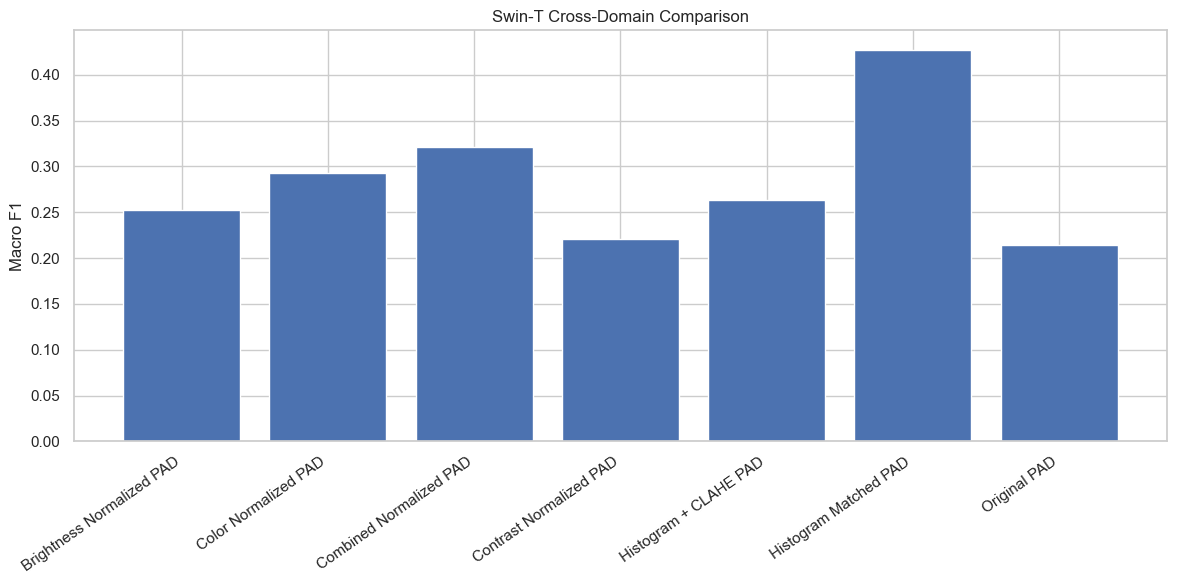

In [17]:
plt.figure(figsize=(12, 6))
plt.bar(comparison["Experiment"], comparison["F1"])
plt.xticks(rotation=35, ha="right")
plt.ylabel("Macro F1")
plt.title("Swin-T Cross-Domain Comparison")
plt.tight_layout()
plt.savefig(OUT_DIR / "swin_f1_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

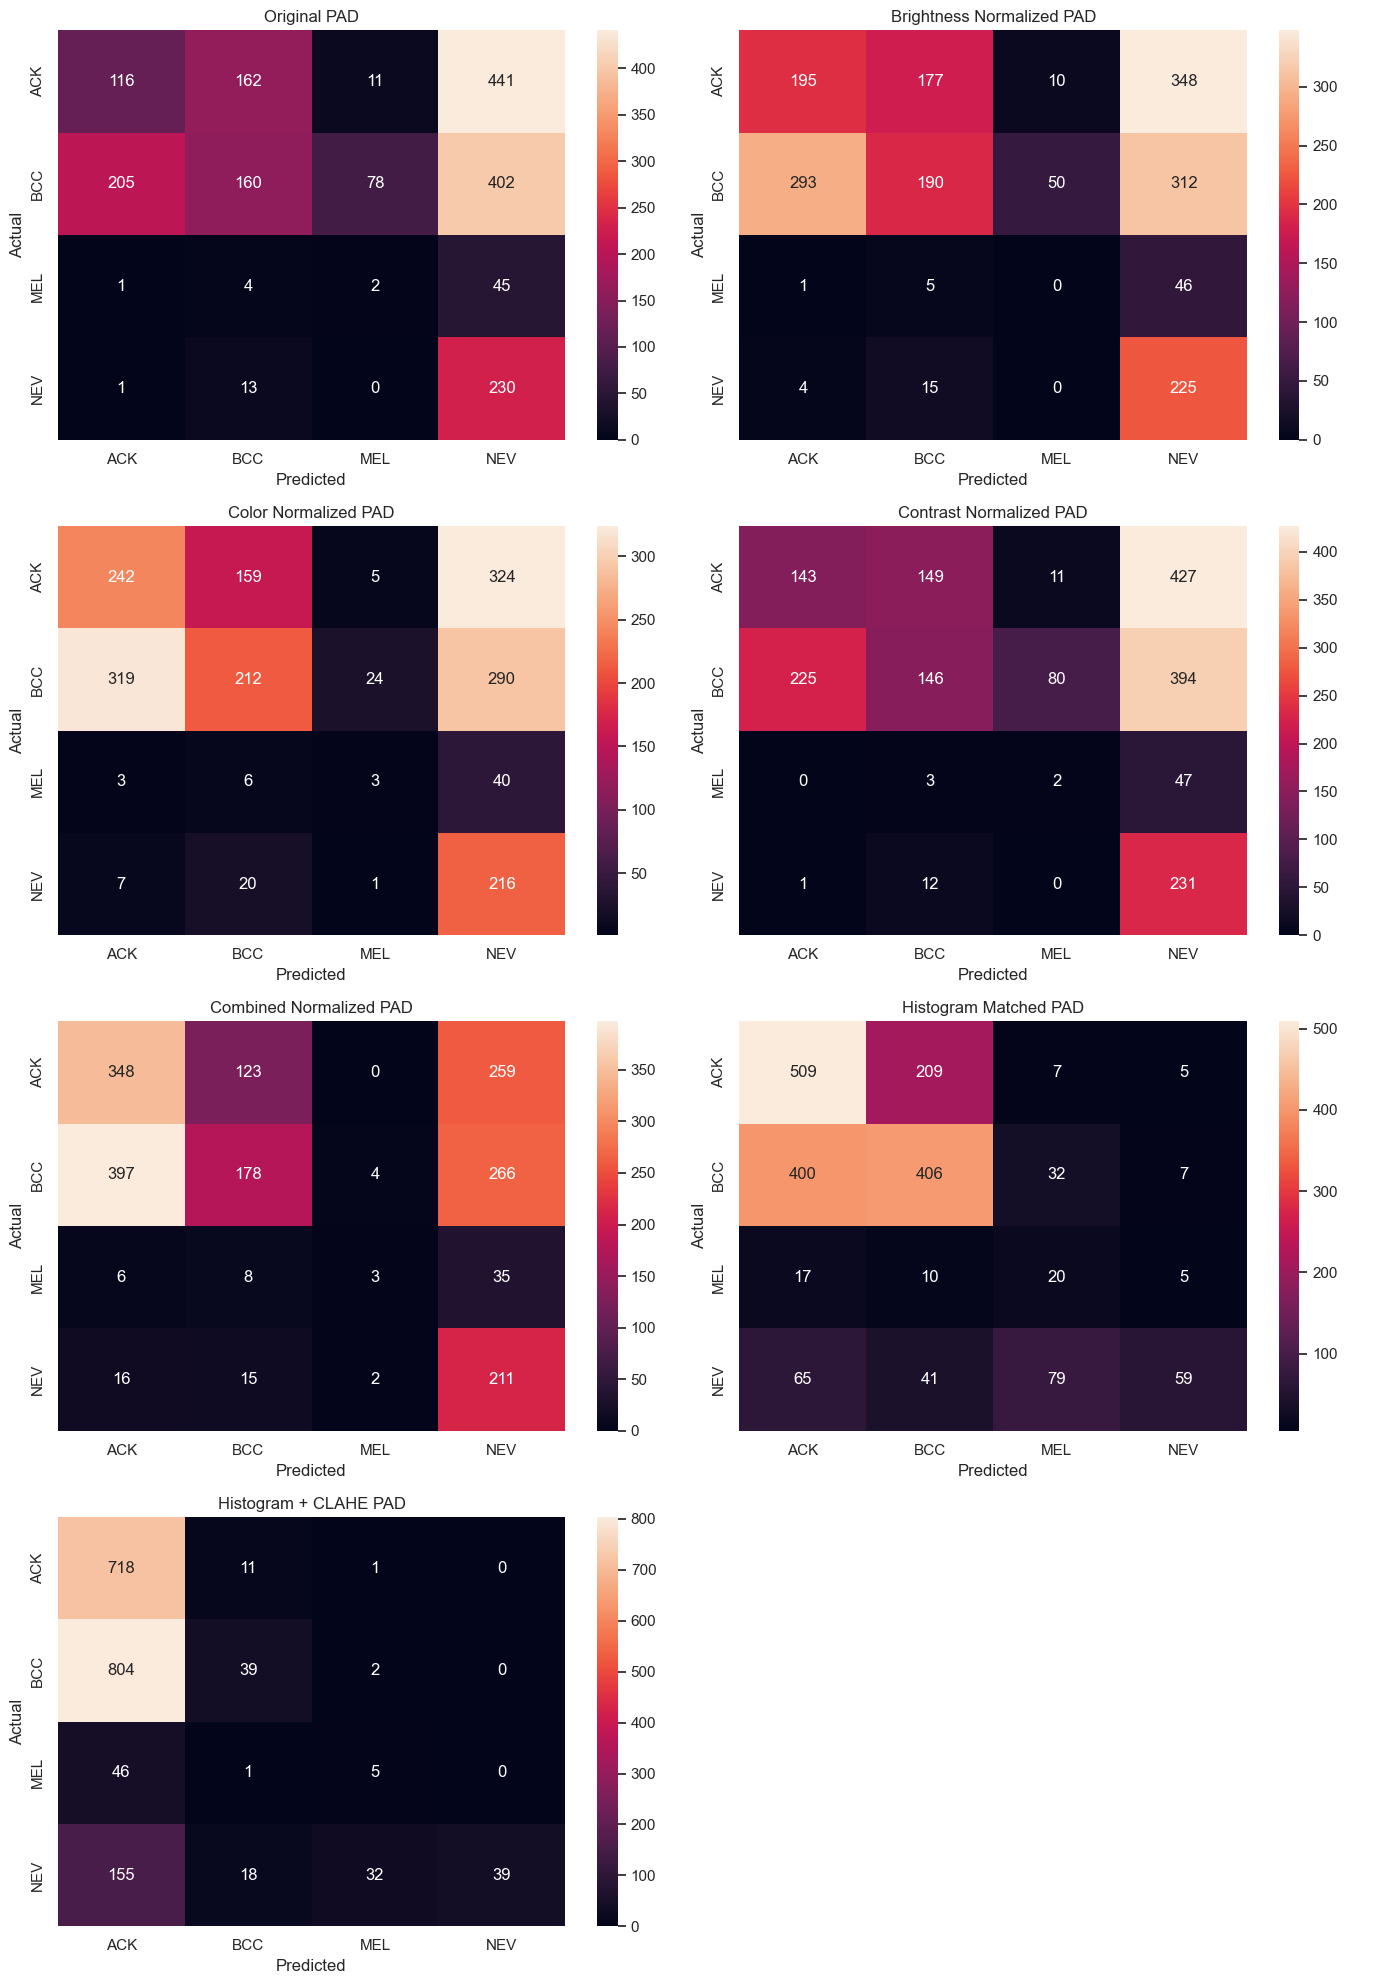

In [18]:
n = len(confusions)
cols = 2
rows = int(np.ceil(n / cols))

fig, axes = plt.subplots(rows, cols, figsize=(14, 5 * rows))
axes = np.array(axes).reshape(-1)

for ax in axes[n:]:
    ax.axis("off")

for ax, (name, cm) in zip(axes, confusions.items()):
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES,
        ax=ax
    )
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.savefig(OUT_DIR / "swin_confusion_matrices.png", dpi=300, bbox_inches="tight")
plt.show()

In [19]:
print("\n--- Swin-T CROSS-DOMAIN SUMMARY ---")
for name, m in results.items():
    print(f"{name}: Accuracy={m['accuracy']:.4f}, F1={m['f1']:.4f}, AUC={m['auc']:.4f}")


--- Swin-T CROSS-DOMAIN SUMMARY ---
Original PAD: Accuracy=0.2715, F1=0.2141, AUC=0.6252
Brightness Normalized PAD: Accuracy=0.3260, F1=0.2526, AUC=0.6414
Color Normalized PAD: Accuracy=0.3597, F1=0.2929, AUC=0.6591
Contrast Normalized PAD: Accuracy=0.2790, F1=0.2212, AUC=0.6310
Combined Normalized PAD: Accuracy=0.3955, F1=0.3209, AUC=0.6912
Histogram Matched PAD: Accuracy=0.5313, F1=0.4270, AUC=0.7557
Histogram + CLAHE PAD: Accuracy=0.4281, F1=0.2638, AUC=0.7139
